In [2]:
import pandas as pd
import numpy as np

# Cargamos el dataset (pandas puede leer el .gz directamente, sin descomprimir a mano)
df = pd.read_csv('../data/accepted_2007_to_2018Q4.csv.gz', low_memory=False)

# Nos quedamos solo con las columnas que vamos a necesitar para el proyecto
cols = ['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
        'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti',
        'issue_d', 'loan_status', 'total_pymnt', 'recoveries', 'out_prncp']
df = df[cols]

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 2260701, Columnas: 16


,loan_amnt,funded_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,issue_d,loan_status,total_pymnt,recoveries,out_prncp
0,3600.0,3600.0,36 months,13.99,C,C4,10+ years,MORTGAGE,55000.0,debt_consolidation,5.91,Dec-2015,Fully Paid,4421.723917,0.0,0.00
1,24700.0,24700.0,36 months,11.99,C,C1,10+ years,MORTGAGE,65000.0,small_business,16.06,Dec-2015,Fully Paid,25679.660000,0.0,0.00
2,20000.0,20000.0,60 months,10.78,B,B4,10+ years,MORTGAGE,63000.0,home_improvement,10.78,Dec-2015,Fully Paid,22705.924294,0.0,0.00
3,35000.0,35000.0,60 months,14.85,C,C5,10+ years,MORTGAGE,110000.0,debt_consolidation,17.06,Dec-2015,Current,31464.010000,0.0,15897.65
4,10400.0,10400.0,60 months,22.45,F,F1,3 years,MORTGAGE,104433.0,major_purchase,25.37,Dec-2015,Fully Paid,11740.500000,0.0,0.00


In [3]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [4]:
# Cartera activa (todavía no cerrada) - para calcular el NPL ratio
activa = df[df['loan_status'].isin(['Current', 'Late (31-120 days)', 'In Grace Period',
                                      'Late (16-30 days)', 'Default'])]

# NPL = préstamos en mora seria (90+ días aprox) sobre el total de la cartera activa
npl = activa[activa['loan_status'].isin(['Late (31-120 days)', 'Default'])]

npl_ratio = len(npl) / len(activa) * 100

print(f"Cartera activa total: {len(activa):,} préstamos")
print(f"Préstamos en NPL: {len(npl):,} préstamos")
print(f"NPL ratio: {npl_ratio:.2f}%")

Cartera activa total: 912,609 préstamos
Préstamos en NPL: 21,507 préstamos
NPL ratio: 2.36%


In [5]:
# Convertimos issue_d (fecha de originación) a formato fecha, y extraemos el año
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year

# Para cada año de originación, calculamos qué % de esos préstamos terminó en default
# Usamos solo los préstamos con resultado definitivo (Fully Paid o Charged Off)
definitivos = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

vintage = definitivos.groupby('issue_year').apply(
    lambda x: (x['loan_status'] == 'Charged Off').mean() * 100
)

print("Tasa de default por año de originación (vintage):")
print(vintage.round(2))

Tasa de default por año de originación (vintage):
issue_year
2007.0    17.93
2008.0    15.81
2009.0    12.60
2010.0    12.89
2011.0    15.18
2012.0    16.20
2013.0    15.60
2014.0    18.45
2015.0    20.18
2016.0    23.28
2017.0    23.12
2018.0    15.75
dtype: float64


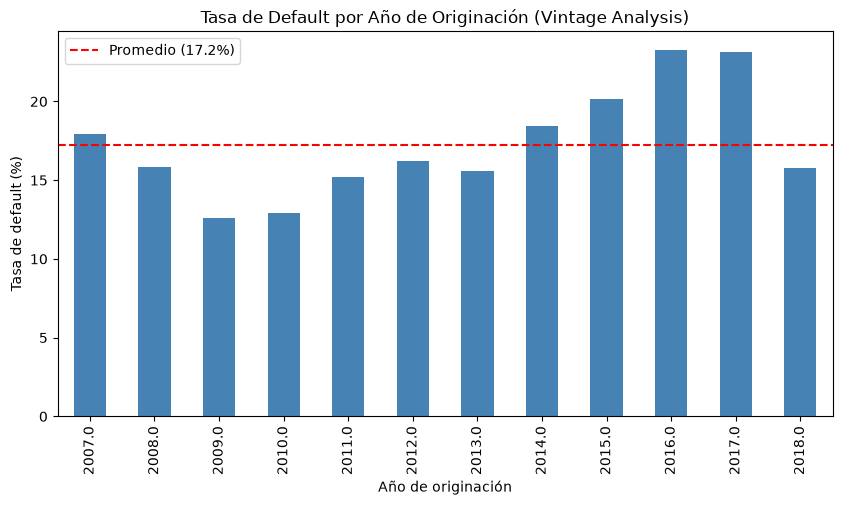

In [6]:
import matplotlib.pyplot as plt

vintage.plot(kind='bar', figsize=(10,5), color='steelblue')
plt.title('Tasa de Default por Año de Originación (Vintage Analysis)')
plt.xlabel('Año de originación')
plt.ylabel('Tasa de default (%)')
plt.axhline(y=vintage.mean(), color='red', linestyle='--', label=f'Promedio ({vintage.mean():.1f}%)')
plt.legend()
plt.show()